# 01 - Exploratory Data Analysis (Module 1)

This notebook loads the ETT datasets, runs basic data-quality checks
(missing values, duplicated timestamps, time continuity) and produces the
core EDA figures (OT trend, multivariate time series, OT distribution,
correlation matrix). Reusable functions live in `src/data/loader.py`.

## 1. Import libraries and project modules

In [ ]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project root importable so we can use code under src/.
PROJECT_ROOT = ".."
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data.loader import (
    load_ett_dataset,
    run_data_quality_report,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
)
from src.viz import apply_paper_style

# Output directories for figures and metrics.
FIG_DIR = "../results/figures"
METRICS_DIR = "../results/metrics"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# Shared publication style so notebook figures match the rest of the thesis.
# The committed EDA figures are regenerated headlessly by
# experiments/make_eda_figures.py, which uses this same style.
sns.set_style("whitegrid")
apply_paper_style()

## 2. Load ETTh1 dataset

We start with `ETTh1.csv` (hourly data). The same code is reused for the other datasets later.

In [2]:
DATA_PATH = "../data/raw/ETTh1.csv"
DATASET_NAME = "ETTh1"
EXPECTED_FREQ = "1h"  # ETTh datasets are hourly; use "15min" for ETTm.

df = load_ett_dataset(DATA_PATH)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


## 3. Basic data structure inspection

In [3]:
print(df.shape)
print(df.info())
df.describe()

(17420, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


## 4. Missing value, timestamp and time-continuity checks

In [4]:
report = run_data_quality_report(
    df=df,
    dataset_name=DATASET_NAME,
    expected_freq=EXPECTED_FREQ,
)

print("Basic Information")
print(report["basic_info"])

print("\nMissing Values")
print(report["missing_values"])

print("\nDuplicated Timestamps")
print(report["duplicated_timestamps"])

print("\nTime Interval Counts")
print(report["time_interval_counts"])

print("\nTime Continuity")
print({
    "expected_frequency": report["time_continuity"]["expected_frequency"],
    "expected_num_timestamps": report["time_continuity"]["expected_num_timestamps"],
    "actual_num_timestamps": report["time_continuity"]["actual_num_timestamps"],
    "missing_num_timestamps": report["time_continuity"]["missing_num_timestamps"],
})

Basic Information
{'dataset': 'ETTh1', 'rows': 17420, 'columns': ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], 'start_date': Timestamp('2016-07-01 00:00:00'), 'end_date': Timestamp('2018-06-26 19:00:00'), 'num_features': 7}

Missing Values
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Duplicated Timestamps
0

Time Interval Counts
date
0 days 01:00:00    17419
Name: count, dtype: int64

Time Continuity
{'expected_frequency': '1h', 'expected_num_timestamps': 17420, 'actual_num_timestamps': 17420, 'missing_num_timestamps': 0}


**Data-quality note.** Record here how the dataset behaves, e.g.
"No missing values were found. No duplicated timestamps. All intervals are exactly 1 hour."
If missing values or gaps exist, document the chosen handling
(forward fill / linear interpolation / row removal) before modelling.

## 5. OT trend over time

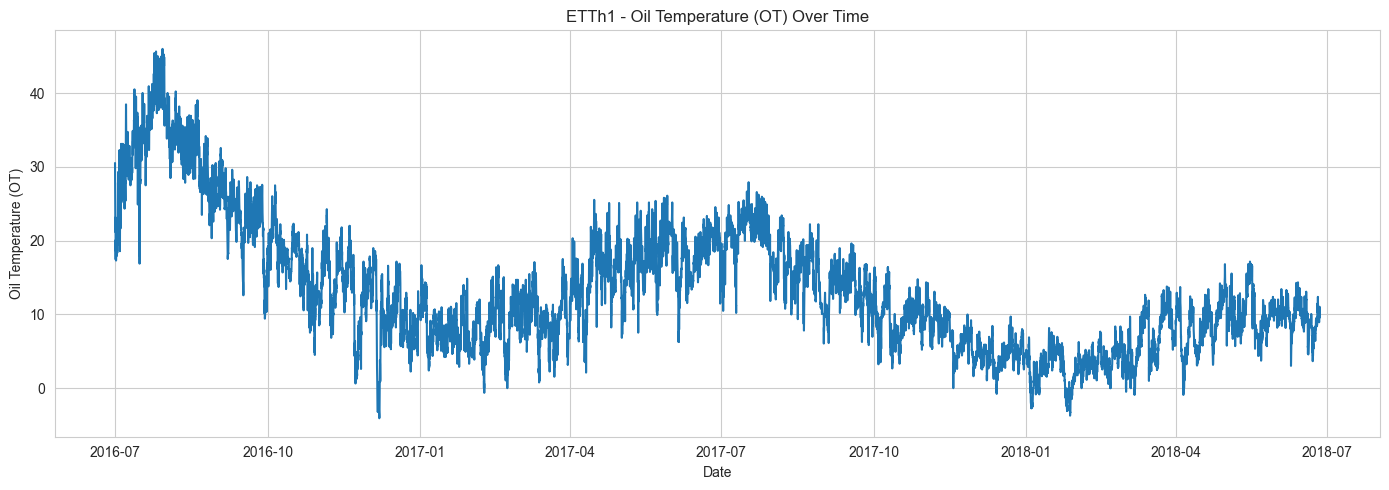

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df[TARGET_COLUMN])
plt.title(f"{DATASET_NAME} - Oil Temperature (OT) Over Time")
plt.xlabel("Date")
plt.ylabel("Oil Temperature (OT)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_ot_trend.png", dpi=300)
plt.show()

## 6. Multivariate feature time series

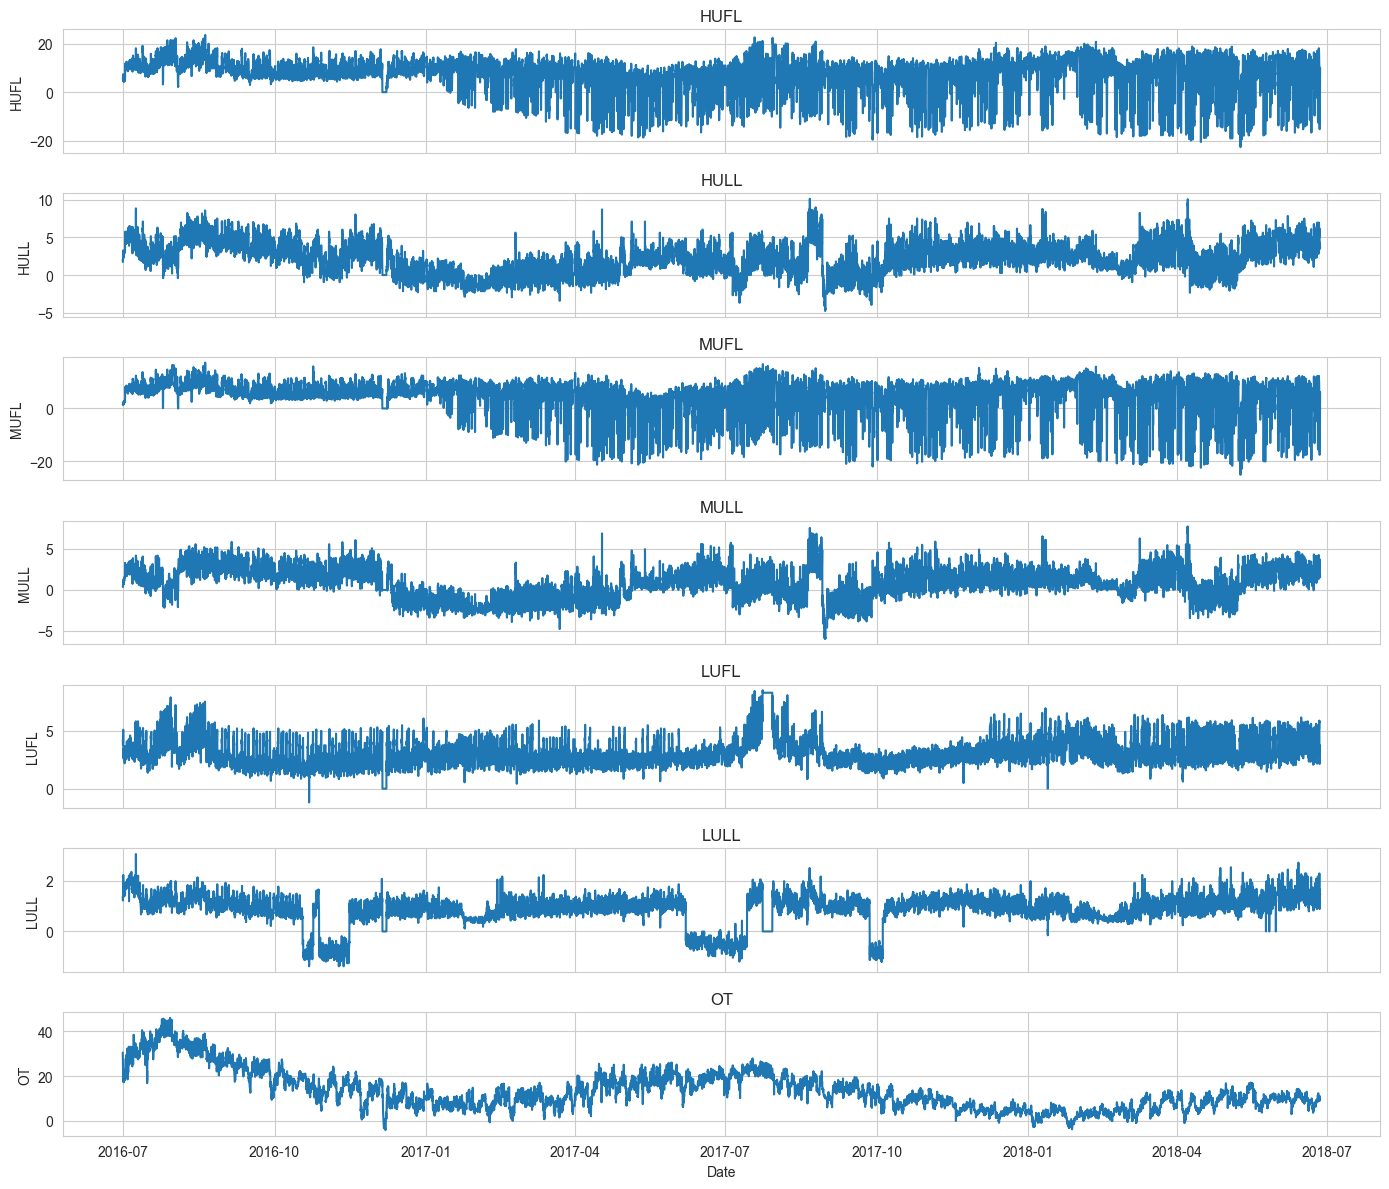

In [6]:
fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1, figsize=(14, 12), sharex=True)
for ax, feature in zip(axes, FEATURE_COLUMNS):
    ax.plot(df["date"], df[feature])
    ax.set_ylabel(feature)
    ax.set_title(feature)
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_feature_timeseries.png", dpi=300)
plt.show()

## 7. OT distribution

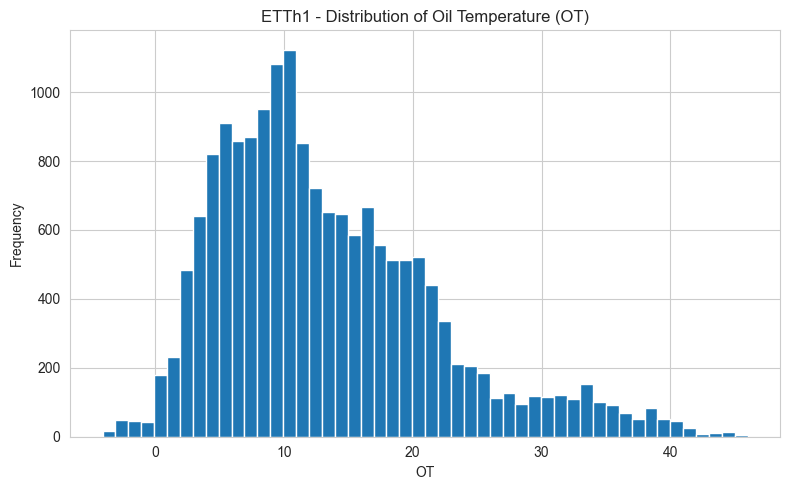

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COLUMN], bins=50)
plt.title(f"{DATASET_NAME} - Distribution of Oil Temperature (OT)")
plt.xlabel("OT")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_ot_distribution.png", dpi=300)
plt.show()

## 8. Feature correlation matrix

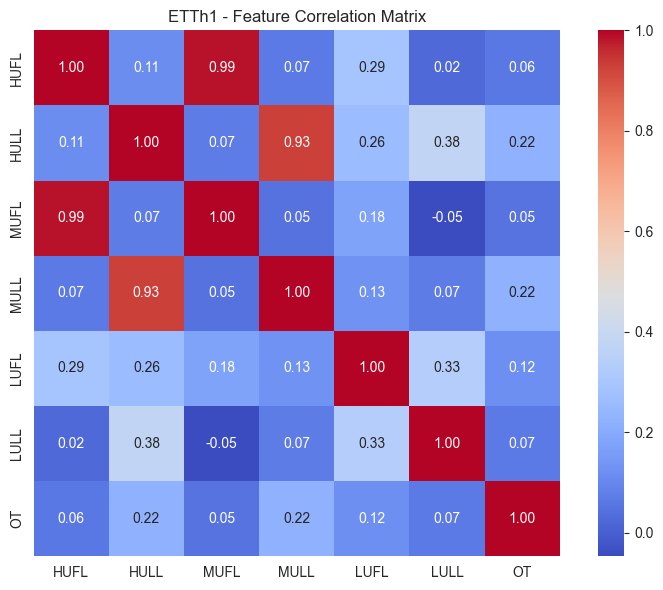

In [8]:
corr = df[FEATURE_COLUMNS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title(f"{DATASET_NAME} - Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_correlation_heatmap.png", dpi=300)
plt.show()

### Interpretation caveat

The correlation matrix is used only as an exploratory analysis. A high
correlation does not necessarily indicate that a variable improves forecasting
performance, and a low correlation does not mean the variable is useless. This
is because correlation only captures linear relationships and does not capture
nonlinear or lagged dependencies (some covariates may relate to *future* OT
rather than current OT). The actual contribution of load-related covariates
will be evaluated through input ablation experiments in Module 3
(OT-only vs. OT + all covariates).

## 9. Basic statistical description

In [9]:
summary_stats = df[FEATURE_COLUMNS].describe().T
summary_stats.to_csv(f"{METRICS_DIR}/eda_summary_statistics.csv")
summary_stats

,count,mean,std,min,25%,50%,75%,max
HUFL,17420.0,7.375141,7.067744,-22.705999,5.827,8.774,11.788,23.643999
HULL,17420.0,2.242242,2.042342,-4.756000,0.737,2.210,3.684,10.114000
MUFL,17420.0,4.300239,6.826978,-25.087999,3.296,5.970,8.635,17.341000
MULL,17420.0,0.881568,1.809293,-5.934000,-0.284,0.959,2.203,7.747000
LUFL,17420.0,3.066062,1.164506,-1.188000,2.315,2.833,3.625,8.498000
LULL,17420.0,0.856932,0.599552,-1.371000,0.670,0.975,1.218,3.046000
OT,17420.0,13.324672,8.566946,-4.080000,6.964,11.396,18.079,46.007000


## 10. Repeat key checks for ETTh2

In [10]:
DATA_PATH_2 = "../data/raw/ETTh2.csv"
DATASET_NAME_2 = "ETTh2"

df2 = load_ett_dataset(DATA_PATH_2)
report2 = run_data_quality_report(
    df=df2,
    dataset_name=DATASET_NAME_2,
    expected_freq="1h",
)

print(report2["basic_info"])
print(report2["missing_values"])
print("Duplicated timestamps:", report2["duplicated_timestamps"])
print(report2["time_interval_counts"])
print("Missing timestamps:", report2["time_continuity"]["missing_num_timestamps"])

{'dataset': 'ETTh2', 'rows': 17420, 'columns': ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], 'start_date': Timestamp('2016-07-01 00:00:00'), 'end_date': Timestamp('2018-06-26 19:00:00'), 'num_features': 7}
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64
Duplicated timestamps: 0
date
0 days 01:00:00    17419
Name: count, dtype: int64
Missing timestamps: 0


## 11. Summary of EDA findings

The ETTh1 dataset was successfully loaded and sorted by timestamp. The `date`
column was converted to datetime format, and the dataset was checked for
missing values, duplicated timestamps and irregular time intervals. The OT
target variable shows clear temporal variation, which supports the use of time
series forecasting models.

The correlation matrix provides an initial overview of linear relationships
between load-related variables and OT. However, correlation is treated only as
exploratory evidence. The actual forecasting value of multivariate covariates
will be evaluated later through controlled input ablation experiments comparing
OT-only inputs with full multivariate inputs.

The checked dataset is suitable for the next stage of Module 1, where
chronological train/validation/test splitting, leakage-free scaling and
sliding-window construction will be implemented.

---
# 12. Time-based split and leakage-free preprocessing (Module 1, sections 5-8)

The steps below implement chronological train/val/test splitting, train-only
scaler fitting, and univariate/multivariate feature control. Strict order:
split -> fit scaler on train only -> transform all splits -> (windowing later).

## 12.1 Imports

In [ ]:
from src.data.splitter import (
    time_based_split,
    get_split_dates,
    print_split_summary,
)
from src.data.preprocessing import (
    prepare_scaled_splits,
    inverse_transform_y,
    print_preprocessing_summary,
)

## 12.2 Chronological split (70 / 10 / 20)

In [ ]:
train_df, val_df, test_df = time_based_split(
    df,
    train_ratio=0.7,
    val_ratio=0.1,
    test_ratio=0.2,
)
print_split_summary(train_df, val_df, test_df)

## 12.3 Keep split dates for later plots (residuals, anomaly markers)

In [ ]:
split_dates = get_split_dates(train_df, val_df, test_df)
print(split_dates)

train_dates = train_df["date"].reset_index(drop=True)
val_dates = val_df["date"].reset_index(drop=True)
test_dates = test_df["date"].reset_index(drop=True)

## 12.4 Multivariate preprocessing (num_features = 7)

In [ ]:
scaled_multi = prepare_scaled_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    input_type="multivariate",
)
print_preprocessing_summary(scaled_multi)

## 12.5 Univariate preprocessing (num_features = 1)

Confirms that `num_features` is derived dynamically and never hard-coded to 7.

In [ ]:
scaled_uni = prepare_scaled_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    input_type="univariate",
)
print_preprocessing_summary(scaled_uni)

## 12.6 Verify scaler_y inverse transform recovers original OT

In [ ]:
y_scaled_sample = scaled_multi["train_y"][:5]
y_original = inverse_transform_y(y_scaled_sample, scaled_multi["scaler_y"])

print("Scaled y:")
print(y_scaled_sample.ravel())
print("Recovered original y:")
print(y_original.ravel())
print("Original OT from dataframe:")
print(train_df[["OT"]].head().values.ravel())

## 12.7 Why scaler_x cannot inverse-transform OT

scaler_x expects 7 columns; scaler_y expects 1. Model outputs are single-column OT, so only scaler_y can invert them correctly.

In [ ]:
print("scaler_x expects n features:", scaled_multi["scaler_x"].n_features_in_)
print("scaler_y expects n features:", scaled_multi["scaler_y"].n_features_in_)

**Stage complete.** We now have:
`raw data -> time-based split -> fit scaler on train only -> transform train/val/test`.

Still to do in Module 1: create sliding windows inside each split and wrap them
in a PyTorch `Dataset` / `DataLoader` (`src/data/dataset.py`).